In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from sklearn.metrics import mean_squared_error
from tensorflow.python.keras.layers import Lambda
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from keras.models import Sequential, Model
from tensorflow.keras.optimizers import RMSprop, Adam
from keras.layers import Dense, LSTM, TimeDistributed, Flatten, Bidirectional, Input
from sklearn.preprocessing import MinMaxScaler
import h5py
import math
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from google.colab import files
from numpy import savetxt

In [ ]:
# Seed
np.random.seed(10)
tf.random.set_seed(10)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the data
data1 = loadmat('/content/drive/My Drive/Colab Notebooks/PINN_Paper_Codes/New_Models/Reference_p5270/Data/p5270_Data.mat')
data2 = loadmat('/content/drive/My Drive/Colab Notebooks/PINN_Paper_Codes/New_Models/Reference_p5270/Data/p5270MechData.mat')
a_t = pd.DataFrame({'Time':data1['LocalAcTime'].ravel().round(2), 'freqQAmpI_filt':data1['freqQAmpI_filt'].ravel()})
w_t = pd.DataFrame({'Time':data1['LocalAcTime'].ravel().round(2),'C_filt':data1['C_filt'].ravel()})
m_t = pd.DataFrame({'Time':data1['Time'].ravel().round(2), 'SS':data1['SS'].ravel()})
s_t = pd.DataFrame({'Time':data2['Time'].ravel().round(2), 'V':data2['V'].ravel(),'V_filt':data2['V_filt'].ravel()})
df = a_t.merge(w_t, on='Time')
df = df.merge(m_t, on='Time')
df = df.merge(s_t, on='Time')
df = df[['freqQAmpI_filt','Time','SS']]
df_SS = df[['freqQAmpI_filt','SS']]
df_A = df[['freqQAmpI_filt','freqQAmpI_filt']]
xdf = df[['freqQAmpI_filt']]
ydf = df[['SS']]

print("Input Data:\n", xdf)
print("Target Data:\n",ydf)

Input Data:
         freqQAmpI_filt
0         31453.223522
1         31438.277060
2         31421.341616
3         31409.798761
4         31398.815589
...                ...
132394    31055.686766
132395    31041.955345
132396    31035.059531
132397    31020.001291
132398    31012.016780

[132399 rows x 1 columns]
Target Data:
               SS
0       5.656166
1       5.657157
2       5.658317
3       5.659499
4       5.660404
...          ...
132394  5.471059
132395  5.474545
132396  5.478286
132397  5.481751
132398  5.484813

[132399 rows x 1 columns]


In [ ]:
import pandas as pd

# Split into train-val-test (SS)
x_train_full, x_test_full, y_train_SS_full, y_test_SS_full = train_test_split(xdf, ydf, test_size=0.2, shuffle=False)
X_train_initial, X_val_initial, Y_train_SS_initial, Y_val_SS_initial = train_test_split(x_train_full, y_train_SS_full, test_size=0.125, shuffle=False)

# Select the training data (inputs & outputs) and capture original indices
sp_train1 = 0
ep_train1 = 30000

sp_train2 = 50000
ep_train2 = 80000

X_train = pd.concat([X_train_initial.iloc[sp_train1:ep_train1], X_train_initial.iloc[sp_train2:ep_train2]])
Y_train_SS = pd.concat([Y_train_SS_initial.iloc[sp_train1:ep_train1], Y_train_SS_initial.iloc[sp_train2:ep_train2]])
Y_train_SS_time_indices = Y_train_SS.index

# Select the validation data (inputs & outputs) and capture original indices
sp_val1 = 0
ep_val1 = 3500

sp_val2 = 5500
ep_val2 = 9000

X_val = pd.concat([X_val_initial.iloc[sp_val1:ep_val1], X_val_initial.iloc[sp_val2:ep_val2]])
Y_val_SS = pd.concat([Y_val_SS_initial.iloc[sp_val1:ep_val1], Y_val_SS_initial.iloc[sp_val2:ep_val2]])
Y_val_SS_time_indices = Y_val_SS.index

# Select the test data (inputs & outputs) and capture original indices
sp_test1 = 5000
ep_test1 = 13000

sp_test2 = 17000
ep_test2 = 25000

x_test = pd.concat([x_test_full.iloc[sp_test1:ep_test1], x_test_full.iloc[sp_test2:ep_test2]])
y_test_SS = pd.concat([y_test_SS_full.iloc[sp_test1:ep_test1], y_test_SS_full.iloc[sp_test2:ep_test2]])
y_test_SS_time_indices = y_test_SS.index


print("Training samples:", np.shape(X_train)[0])
print("Validation samples:", np.shape(X_val)[0])
print("Testing samples:", np.shape(x_test)[0])

Training samples: 60000
Validation samples: 7000
Testing samples: 16000


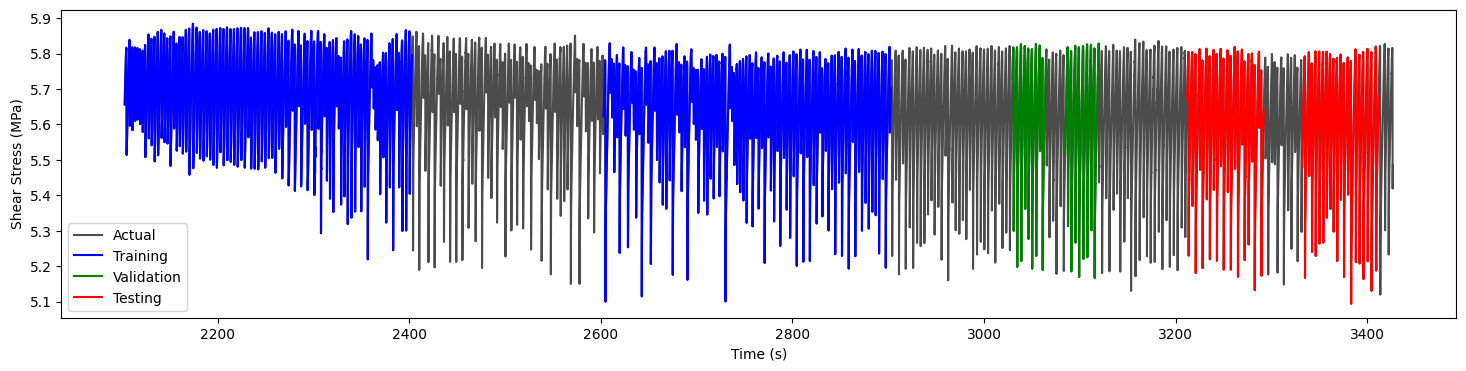

In [ ]:
# Plot data
plt.figure(figsize=(18, 4))
plt.plot(df['Time'], df['SS'], label='Actual', color='black', alpha=0.7)

# Plot Training segments
plt.plot(df['Time'].loc[Y_train_SS_initial.iloc[sp_train1:ep_train1].index], Y_train_SS_initial.iloc[sp_train1:ep_train1], label='Training', color='blue')
plt.plot(df['Time'].loc[Y_train_SS_initial.iloc[sp_train2:ep_train2].index], Y_train_SS_initial.iloc[sp_train2:ep_train2], color='blue') # No label for second segment to avoid duplicate legend entries

# Plot Validation segments
plt.plot(df['Time'].loc[Y_val_SS_initial.iloc[sp_val1:ep_val1].index], Y_val_SS_initial.iloc[sp_val1:ep_val1], label='Validation', color='green')
plt.plot(df['Time'].loc[Y_val_SS_initial.iloc[sp_val2:ep_val2].index], Y_val_SS_initial.iloc[sp_val2:ep_val2], color='green') # No label for second segment

# Plot Testing segments
plt.plot(df['Time'].loc[y_test_SS_full.iloc[sp_test1:ep_test1].index], y_test_SS_full.iloc[sp_test1:ep_test1], label='Testing', color='red')
plt.plot(df['Time'].loc[y_test_SS_full.iloc[sp_test2:ep_test2].index], y_test_SS_full.iloc[sp_test2:ep_test2], color='red') # No label for second segment

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
# plt.title('Data Splits Over Time')
plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
# Normalize the input
scaler = MinMaxScaler()

# Convert to numpy arrays before scaling to avoid potential issues
print(f"Shape of X_train before scaling: {X_train.shape}")
if X_train.empty: raise ValueError("X_train is empty before scaling.")
X_train = pd.DataFrame(scaler.fit_transform(X_train.to_numpy()), columns=X_train.columns)

print(f"Shape of X_val before scaling: {X_val.shape}")
if X_val.empty: raise ValueError("X_val is empty before scaling.")
X_val = pd.DataFrame(scaler.transform(X_val.to_numpy()), columns=X_val.columns)

print(f"Shape of x_test before scaling: {x_test.shape}")
if x_test.empty: raise ValueError("x_test is empty before scaling.")
x_test = pd.DataFrame(scaler.transform(x_test.to_numpy()), columns=x_test.columns)


Shape of X_train before scaling: (60000, 1)
Shape of X_val before scaling: (7000, 1)
Shape of x_test before scaling: (16000, 1)


In [ ]:
# Normalize the output
scaler_ss = MinMaxScaler()
Y_train_SS = pd.DataFrame(scaler_ss.fit_transform(Y_train_SS))
Y_val_SS = pd.DataFrame(scaler_ss.transform(Y_val_SS))
y_test_SS = pd.DataFrame(scaler_ss.transform(y_test_SS))

In [ ]:
# Function: Create Data History
def create_timesteps(data, n_steps):
	x = []
	y = []
	for i in range(len(data)-1):
		end_ix = i + n_steps
		if end_ix > len(data)-1:
			break
		x1, y1 = data[i:end_ix, :-1], data[end_ix, -1]
		x.append(x1)
		y.append(y1)
	return np.array(x), np.array(y)

In [ ]:
# Pre process training
combined_train_data = pd.concat([X_train, Y_train_SS], axis=1)
arr_train = combined_train_data.to_numpy()
n_steps = 300
X_train, Y_train_SS = create_timesteps(arr_train, n_steps)

in_dim = X_train.shape[1]*X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], in_dim))
print('Training Input Shape, X = ', np.shape(X_train))

print('Training Output Shape, Y = ', np.shape(Y_train_SS))

Training Input Shape, X =  (59700, 300)
Training Output Shape, Y =  (59700,)


In [ ]:
# Pre process validation
combined_val_data = pd.concat([X_val, Y_val_SS], axis=1)
arr_val = combined_val_data.to_numpy()
n_steps = 300
X_val, Y_val_SS = create_timesteps(arr_val, n_steps)

in_dim = X_val.shape[1]*X_val.shape[2]
X_val = X_val.reshape((X_val.shape[0], in_dim))
print('Validation Input Shape, X = ', np.shape(X_val))

print('Validation Output Shape, Y = ', np.shape(Y_val_SS))

Validation Input Shape, X =  (6700, 300)
Validation Output Shape, Y =  (6700,)


In [ ]:
# Pre process testing
combined_test_data = pd.concat([x_test, y_test_SS], axis=1)
arr_test = combined_test_data.to_numpy()
n_steps = 300
x_test, y_test_SS = create_timesteps(arr_test, n_steps)

in_dim = x_test.shape[1]*x_test.shape[2]
x_test = x_test.reshape((x_test.shape[0], in_dim))
print('Testing Input Shape, X = ', np.shape(x_test))

print('Testing Output Shape, Y = ', np.shape(y_test_SS))

Testing Input Shape, X =  (15700, 300)
Testing Output Shape, Y =  (15700,)


**Define Data-Driven Model**

In [ ]:
# Define DD
def MLP_Data():

  # Define inputs
  X_train = layers.Input(shape=(300,),name='X_train')

  # Prediction: Shear Stress + Slip Rate
  x = layers.Dense(128,kernel_initializer = 'normal', activation="relu")(X_train)
  x = layers.Dense(64,kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(32,kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(16, kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(8, kernel_initializer = 'normal', activation="relu")(x)
  ss_pred = layers.Dense(1,kernel_initializer = 'normal',activation="linear")(x)

  model = keras.Model(inputs=[X_train],outputs=[ss_pred])
  return model

In [ ]:
# Model Summary
model=MLP_Data()
model.compile(loss='mse', optimizer= tf.keras.optimizers.Adam(1e-3), metrics=['mse'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ X_train (InputLayer)            │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,537 (193.50 KB)

 Trainable params: 49,537 (193.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1854/1866 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0786 - mse: 0.0786
Epoch 1: val_loss improved from None to 0.02187, saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_2/Check/Check_10.keras

Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_2/Check/Check_10.keras
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0332 - mse: 0.0332 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 2/100
1856/1866 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0138 - mse: 0.0138
Epoch 2: val_loss improved from 0.02187 to 0.01817, saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_2/Check/Check_10.keras

Epoch 2: finished saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Ha

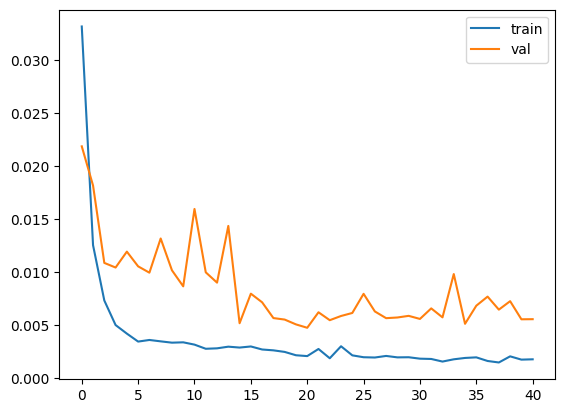

---Training time: 261.11911964 seconds ---


In [ ]:
# Train The Model
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=20,verbose=1, mode='auto')
checkpoint = ModelCheckpoint('/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_2/Check/Check_10.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
callbacks_list = [earlystop, checkpoint]
start_time = time.time()
history = model.fit([X_train],[Y_train_SS], epochs=100, batch_size=32,callbacks=callbacks_list,
                     validation_data=([X_val],[Y_val_SS]), verbose=1)
end_time = time.time()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()
print("---Training time: %0.8f seconds ---" % (end_time - start_time))

In [ ]:
# Model Performance: Training
y_predtrain = model.predict([X_train])
y_predtrain_SS = np.array(y_predtrain)

train_r2_SS = r2_score(Y_train_SS, y_predtrain_SS)
train_rmse_SS = np.sqrt(mean_squared_error(Y_train_SS, y_predtrain_SS))

# Model Performance: Validation
y_predval = model.predict([X_val])
y_predval_SS = np.array(y_predval)

val_r2_SS = r2_score(Y_val_SS, y_predval_SS)
val_rmse_SS = np.sqrt(mean_squared_error(Y_val_SS, y_predval_SS))

# Model Performance: Testing
y_predtest = model.predict([x_test])
y_predtest_SS =np.array(y_predtest)

test_r2_SS = r2_score(y_test_SS,y_predtest_SS)
test_rmse_SS = np.sqrt(mean_squared_error(y_test_SS, y_predtest_SS))

# Print R2 Results
print("R2 scores: Train (SS) - %0.5f" %(train_r2_SS))
print("R2 scores: Validation (SS) - %0.5f" %(val_r2_SS))
print("R2 scores: Testing (SS) - %0.5f" %(test_r2_SS))

1866/1866 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
R2 scores: Train (SS) - 0.95013
R2 scores: Validation (SS) - 0.84373
R2 scores: Testing (SS) - 0.78426


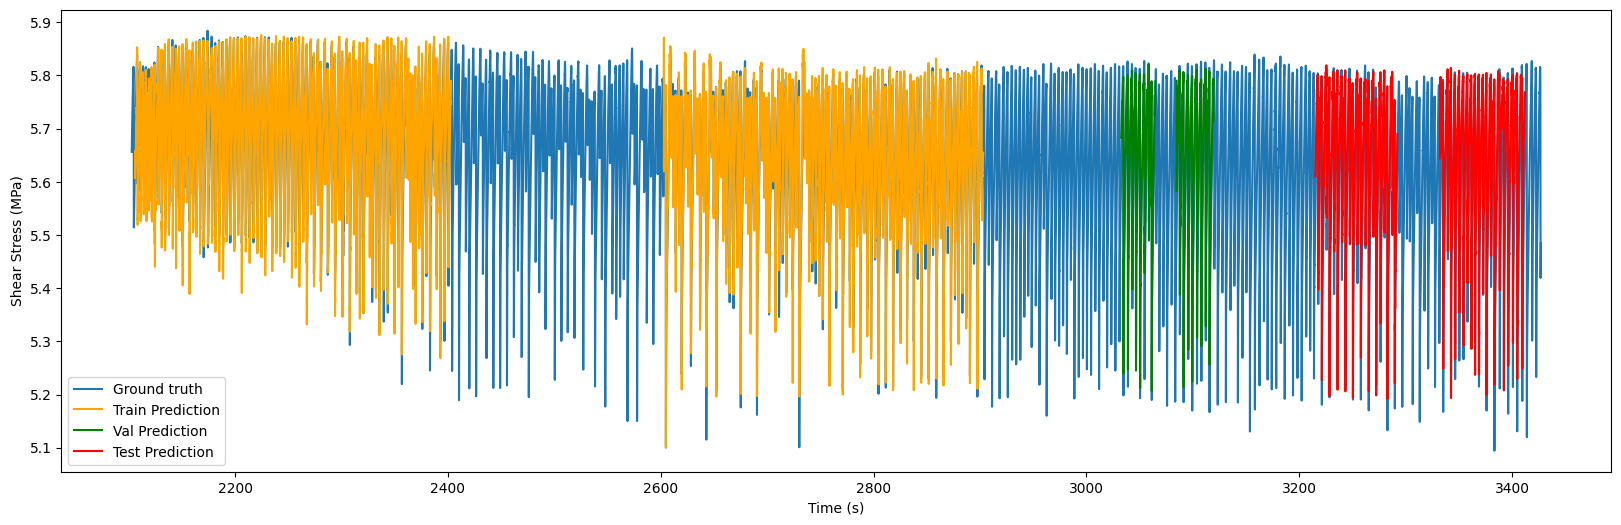

In [ ]:
# Overall plots

# Denormalize the predictions
y_predtrain_SS_denorm = scaler_ss.inverse_transform(y_predtrain_SS)
y_predval_SS_denorm = scaler_ss.inverse_transform(y_predval_SS)
y_predtest_SS_denorm = scaler_ss.inverse_transform(y_predtest_SS)

# Get the actual time indices for the predictions, accounting for n_steps
traintime = df['Time'].loc[Y_train_SS_time_indices[n_steps:]]
valtime = df['Time'].loc[Y_val_SS_time_indices[n_steps:]]
testtime = df['Time'].loc[y_test_SS_time_indices[n_steps:]]

## SS
fig = plt.figure(1, figsize=(20,6))
plt.plot(df['Time'], df['SS'], label='Ground truth') # Plot entire original data as ground truth

# Split and plot Training Prediction segments
len_train_seg1 = ep_train1 - sp_train1
split_point_train = len_train_seg1 - n_steps
plt.plot(traintime.iloc[:split_point_train], y_predtrain_SS_denorm[:split_point_train], label='Train Prediction', color='orange')
plt.plot(traintime.iloc[split_point_train:], y_predtrain_SS_denorm[split_point_train:], color='orange') # No label for second segment

# Split and plot Validation Prediction segments
len_val_seg1 = ep_val1 - sp_val1
split_point_val = len_val_seg1 - n_steps
plt.plot(valtime.iloc[:split_point_val], y_predval_SS_denorm[:split_point_val], label='Val Prediction', color='green')
plt.plot(valtime.iloc[split_point_val:], y_predval_SS_denorm[split_point_val:], color='green') # No label for second segment

# Split and plot Testing Prediction segments
len_test_seg1 = ep_test1 - sp_test1
split_point_test = len_test_seg1 - n_steps
plt.plot(testtime.iloc[:split_point_test], y_predtest_SS_denorm[:split_point_test], label='Test Prediction', color='red')
plt.plot(testtime.iloc[split_point_test:], y_predtest_SS_denorm[split_point_test:], color='red') # No label for second segment

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
# plt.title('Shear Stress Prediction (Non-Consecutive Segments)')
plt.legend()
# plt.grid(True)
plt.show()

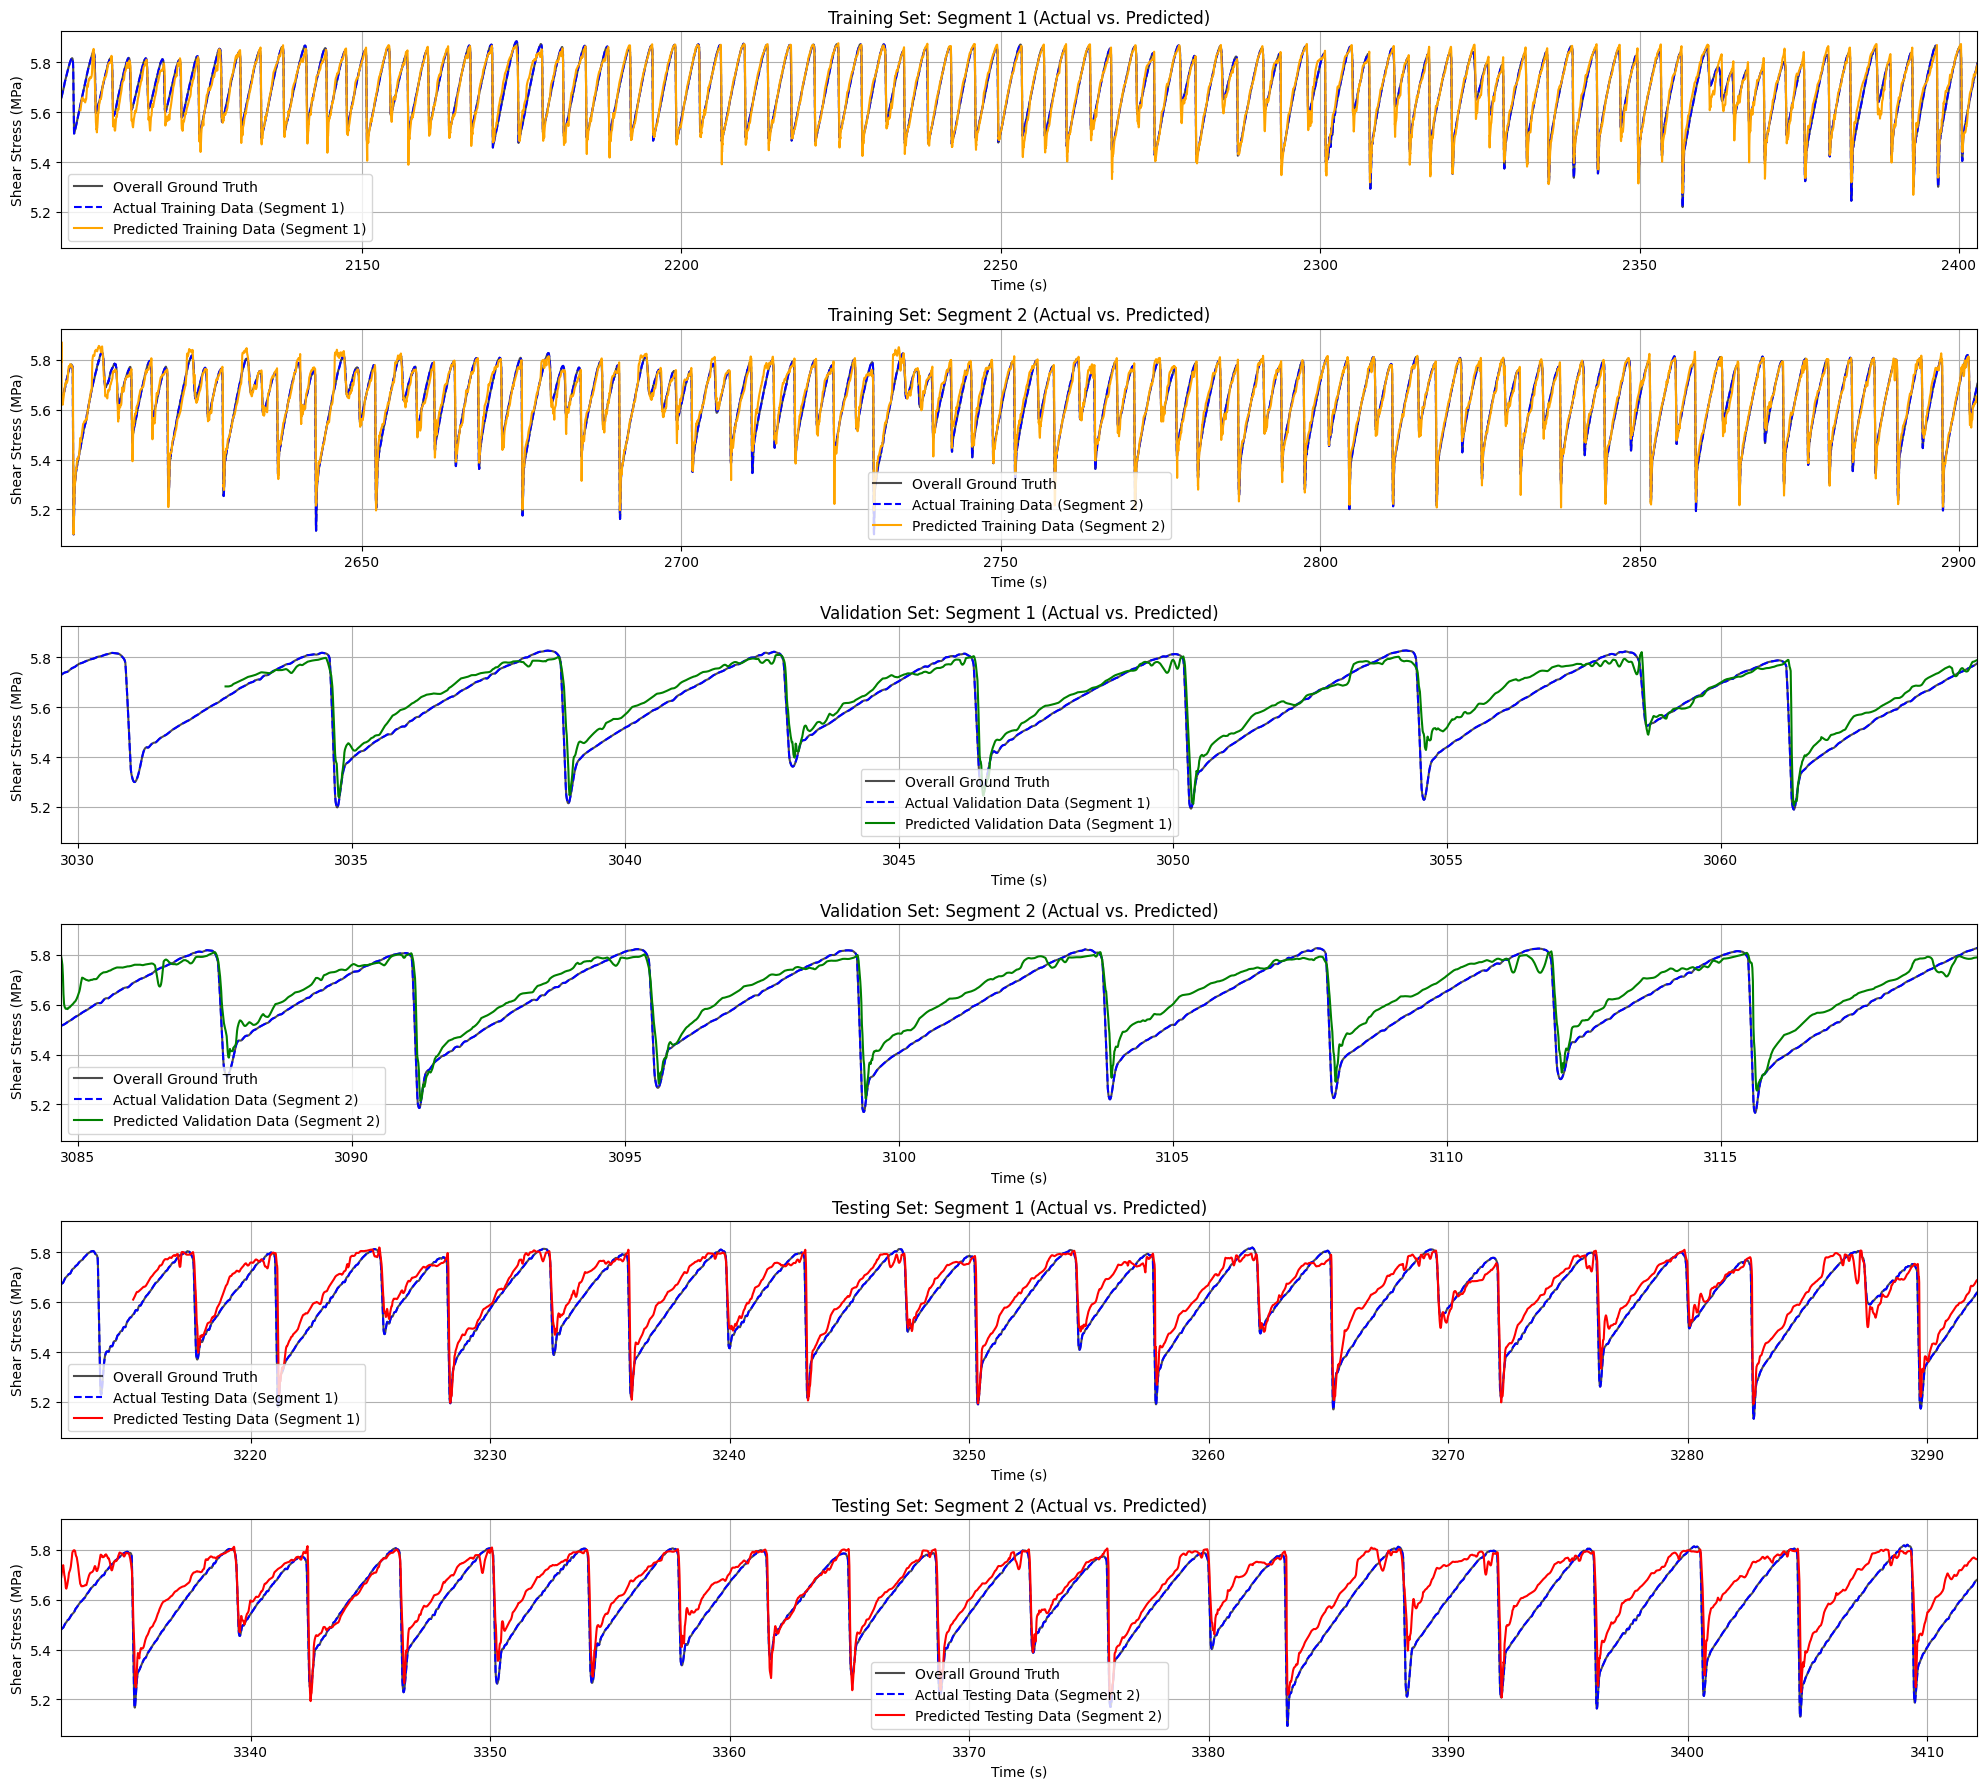

In [ ]:
# Plot for Training Set - Separate Subplots for each segment
plt.figure(figsize=(20, 18)) # Adjusted figure size for all 6 subplots

# Subplot 1: Training Segment 1
plt.subplot(6, 1, 1)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Training Segment 1
actual_train_seg1_time = df['Time'].loc[Y_train_SS_initial.iloc[sp_train1:ep_train1].index]
actual_train_seg1_data = Y_train_SS_initial.iloc[sp_train1:ep_train1]
plt.plot(actual_train_seg1_time, actual_train_seg1_data, label='Actual Training Data (Segment 1)', color='blue', linestyle='--')

# Predicted Training Segment 1
predicted_train_seg1_time = traintime.iloc[:split_point_train]
predicted_train_seg1_data = y_predtrain_SS_denorm[:split_point_train]
plt.plot(predicted_train_seg1_time, predicted_train_seg1_data, label='Predicted Training Data (Segment 1)', color='orange')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Training Set: Segment 1 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_train_seg1_time.min(), actual_train_seg1_time.max())

# Subplot 2: Training Segment 2
plt.subplot(6, 1, 2)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Training Segment 2
actual_train_seg2_time = df['Time'].loc[Y_train_SS_initial.iloc[sp_train2:ep_train2].index]
actual_train_seg2_data = Y_train_SS_initial.iloc[sp_train2:ep_train2]
plt.plot(actual_train_seg2_time, actual_train_seg2_data, label='Actual Training Data (Segment 2)', color='blue', linestyle='--')

# Predicted Training Segment 2
predicted_train_seg2_time = traintime.iloc[split_point_train:]
predicted_train_seg2_data = y_predtrain_SS_denorm[split_point_train:]
plt.plot(predicted_train_seg2_time, predicted_train_seg2_data, label='Predicted Training Data (Segment 2)', color='orange')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Training Set: Segment 2 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_train_seg2_time.min(), actual_train_seg2_time.max())

# Plot for Validation Set - Separate Subplots for each segment
# plt.figure(figsize=(20, 6)) # Removed to plot on the same figure

# Subplot 1: Validation Segment 1
plt.subplot(6, 1, 3)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Validation Segment 1
actual_val_seg1_time = df['Time'].loc[Y_val_SS_initial.iloc[sp_val1:ep_val1].index]
actual_val_seg1_data = Y_val_SS_initial.iloc[sp_val1:ep_val1]
plt.plot(actual_val_seg1_time, actual_val_seg1_data, label='Actual Validation Data (Segment 1)', color='blue', linestyle='--')

# Predicted Validation Segment 1
predicted_val_seg1_time = valtime.iloc[:split_point_val]
predicted_val_seg1_data = y_predval_SS_denorm[:split_point_val]
plt.plot(predicted_val_seg1_time, predicted_val_seg1_data, label='Predicted Validation Data (Segment 1)', color='green')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Validation Set: Segment 1 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_val_seg1_time.min(), actual_val_seg1_time.max())

# Subplot 2: Validation Segment 2
plt.subplot(6, 1, 4)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Validation Segment 2
actual_val_seg2_time = df['Time'].loc[Y_val_SS_initial.iloc[sp_val2:ep_val2].index]
actual_val_seg2_data = Y_val_SS_initial.iloc[sp_val2:ep_val2]
plt.plot(actual_val_seg2_time, actual_val_seg2_data, label='Actual Validation Data (Segment 2)', color='blue', linestyle='--')

# Predicted Validation Segment 2
predicted_val_seg2_time = valtime.iloc[split_point_val:]
predicted_val_seg2_data = y_predval_SS_denorm[split_point_val:]
plt.plot(predicted_val_seg2_time, predicted_val_seg2_data, label='Predicted Validation Data (Segment 2)', color='green')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Validation Set: Segment 2 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_val_seg2_time.min(), actual_val_seg2_time.max())

# Plot for Testing Set - Separate Subplots for each segment
# plt.figure(figsize=(20, 6)) # Removed to plot on the same figure

# Subplot 1: Testing Segment 1
plt.subplot(6, 1, 5)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Testing Segment 1
actual_test_seg1_time = df['Time'].loc[y_test_SS_full.iloc[sp_test1:ep_test1].index]
actual_test_seg1_data = y_test_SS_full.iloc[sp_test1:ep_test1]
plt.plot(actual_test_seg1_time, actual_test_seg1_data, label='Actual Testing Data (Segment 1)', color='blue', linestyle='--')

# Predicted Testing Segment 1
predicted_test_seg1_time = testtime.iloc[:split_point_test]
predicted_test_seg1_data = y_predtest_SS_denorm[:split_point_test]
plt.plot(predicted_test_seg1_time, predicted_test_seg1_data, label='Predicted Testing Data (Segment 1)', color='red')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Testing Set: Segment 1 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_test_seg1_time.min(), actual_test_seg1_time.max())

# Subplot 2: Testing Segment 2
plt.subplot(6, 1, 6)
plt.plot(df['Time'], df['SS'], label='Overall Ground Truth', color='black', alpha=0.7)

# Actual Testing Segment 2
actual_test_seg2_time = df['Time'].loc[y_test_SS_full.iloc[sp_test2:ep_test2].index]
actual_test_seg2_data = y_test_SS_full.iloc[sp_test2:ep_test2]
plt.plot(actual_test_seg2_time, actual_test_seg2_data, label='Actual Testing Data (Segment 2)', color='blue', linestyle='--')

# Predicted Testing Segment 2
predicted_test_seg2_time = testtime.iloc[split_point_test:]
predicted_test_seg2_data = y_predtest_SS_denorm[split_point_test:]
plt.plot(predicted_test_seg2_time, predicted_test_seg2_data, label='Predicted Testing Data (Segment 2)', color='red')

plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
plt.title('Testing Set: Segment 2 (Actual vs. Predicted)')
plt.legend()
plt.grid(True)
plt.xlim(actual_test_seg2_time.min(), actual_test_seg2_time.max())

plt.tight_layout()
plt.show()